A script to compute the zonal wavenumber of the Lamb wave in a numerical simulation.
Use this to examine the regime we are in, relative to the wavenumbers of acoustic and gravity waves

In [3]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
import pywt

In [4]:
# SE result:
se_case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb'
se_run_base = '/glade/derecho/scratch/nforcone/'
se_nc_file = se_case + '.cam.h0i.0001-01-01-00000.nc'

fv3_case = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_dt_1min'
fv3_run_base = "/glade/derecho/scratch/timand/"
fv3_nc_file = fv3_case + '.cam.h0i.0001-01-01-00000_p_pert.regrid.1x1.nc'

mpas_case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
mpas_run_base = '/glade/derecho/scratch/cjablono/'    
mpas_nc_file = mpas_case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.epssm_0.1.cpair_default.50hPa.nc'

se_run_path = se_run_base + se_case + '/run/' + se_nc_file
fv3_run_path = fv3_run_base + fv3_case + '/run/' + fv3_nc_file
mpas_run_path = mpas_run_base + mpas_case + '/run/' + mpas_nc_file

nc_se = Dataset(se_run_path, 'r')
nc_fv3 = Dataset(fv3_run_path, 'r')
nc_mpas = Dataset(mpas_run_path, 'r')


In [5]:
time = nc_fv3['time'][:]
lat_deg = nc_fv3['lat'][:] 
lon_deg = nc_fv3['lon'][:] 

# Work in radians
lat = lat_deg*np.pi/180
lon = lon_deg*np.pi/180

LON, LAT = np.meshgrid(lon_deg, lat_deg)

print(np.min(lon))
print(np.max(lon))
print(np.min(lat))
print(np.max(lat))

0.0
6.265732014659642
-1.5707963267948966
1.5707963267948966


In [6]:
# Choose the field and time index to look at
t_idx = 60
t_min = int(np.round(time[t_idx]*24*60, 0))

field_name = 'PS'
field_se = nc_se[field_name][:]
field_fv3 = nc_fv3[field_name][:]
field_mpas = nc_mpas[field_name][:]

print(np.shape(field_fv3))

(1081, 181, 360)


[ 0.  5. 10. 15. 20. 25. 30. 35. 40. 45. 50.]


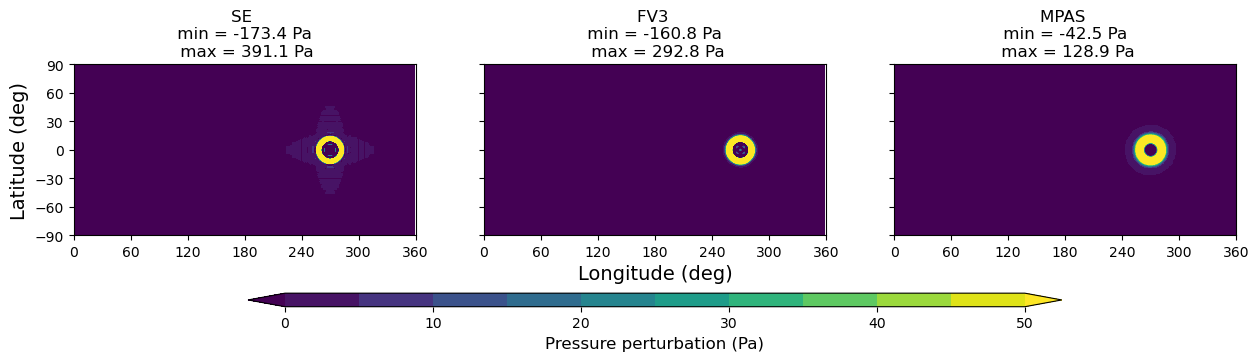

In [7]:
# What about comparing the fields??
p0 = 1e5

if field_name == 'PS':
    se_plot = field_se[t_idx, :, :]-p0
    fv3_plot = field_fv3[t_idx, :, :]-p0
    mpas_plot = field_mpas[t_idx, :, :]-p0
    conts = np.linspace(0,50,11)
    cmap='viridis'
else:
    se_plot = field_se[t_idx, :, :]
    fv3_plot = field_fv3[t_idx, :, :]
    mpas_plot = field_mpas[t_idx, :, :]

print(conts)

fig, axes = plt.subplots(1,3, figsize=(15,5), sharey = True)
ax1, ax2, ax3 = axes

plot1 = ax1.contourf(LON, LAT, se_plot, levels = conts, extend='both', cmap=cmap)
plot2 = ax2.contourf(LON, LAT, fv3_plot, levels = conts, extend='both', cmap=cmap)
plot3 = ax3.contourf(LON, LAT, mpas_plot, levels = conts, extend='both', cmap=cmap)

cb = plt.colorbar(plot3, ax=axes, shrink=0.7, pad=0.15, aspect=60, location='bottom')
if field_name == 'PS':
    ax1.set_title(f'SE \n min = {np.min(se_plot):.1f} Pa \n max = {np.max(se_plot):.1f} Pa')
    ax2.set_title(f'FV3 \n min = {np.min(fv3_plot):.1f} Pa \n max = {np.max(fv3_plot):.1f} Pa')
    ax3.set_title(f'MPAS \n min = {np.min(mpas_plot):.1f} Pa \n max = {np.max(mpas_plot):.1f} Pa')
    cb.set_label('Pressure perturbation (Pa)', size=12)
elif field_name == 'OMEGA850':
    ax1.set_title(f'SE \n min = {np.min(se_plot):.1f} \n max = {np.max(se_plot):.1f}')
    ax2.set_title(f'FV3 \n min = {np.min(fv3_plot):.1f} \n max = {np.max(fv3_plot):.1f}')
    ax3.set_title(f'MPAS \n min = {np.min(mpas_plot):.1f} \n max = {np.max(mpas_plot):.1f}')
    cb.set_label(r'Maximum vertical pressure velocity (Pa s$^{-1}$', size=12)

ax1.set_ylabel('Latitude (deg)', size=14)
ax2.set_xlabel('Longitude (deg)', size=14)

for ax in axes.flatten():
    ax.set_xticks(np.linspace(0,360,7))
    ax.set_aspect('equal')
    
ax2.set_xticks(np.linspace(0,360,7))
ax3.set_xticks(np.linspace(0,360,7))
ax1.set_yticks(np.linspace(-90,90,7))

plt.show()


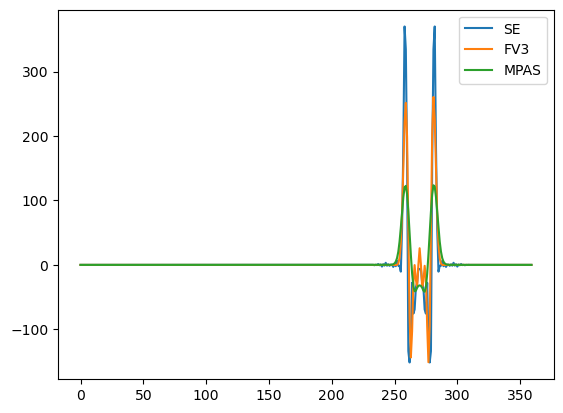

In [8]:
# Extract the values at the equator and then compare
lat_val = 90
se_eq = field_se[t_idx, lat_val, :]-p0
fv3_eq = field_fv3[t_idx, lat_val, :]-p0
mpas_eq = field_mpas[t_idx, lat_val, :]-p0

plt.figure()
plt.plot(lon_deg, se_eq, label='SE')
plt.plot(lon_deg, fv3_eq, label='FV3')
plt.plot(lon_deg, mpas_eq, label='MPAS')
plt.legend()
plt.show()

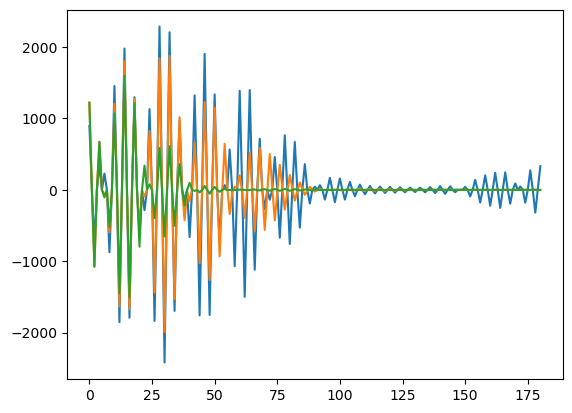

In [18]:
# Compute the fft
se_eq_fft = np.fft.rfft(se_eq)
fv3_eq_fft = np.fft.rfft(fv3_eq)
mpas_eq_fft = np.fft.rfft(mpas_eq)

dx_deg = 1.0
n = len(se_eq)
freq_cyc_per_deg = np.fft.rfftfreq(n=n, d=dx_deg)
k_vals = 360*freq_cyc_per_deg

plt.figure()
plt.plot(k_vals, se_eq_fft, label='SE')
plt.plot(k_vals, fv3_eq_fft, label='FV3')
plt.plot(k_vals, mpas_eq_fft, label='MPAS')
plt.show()

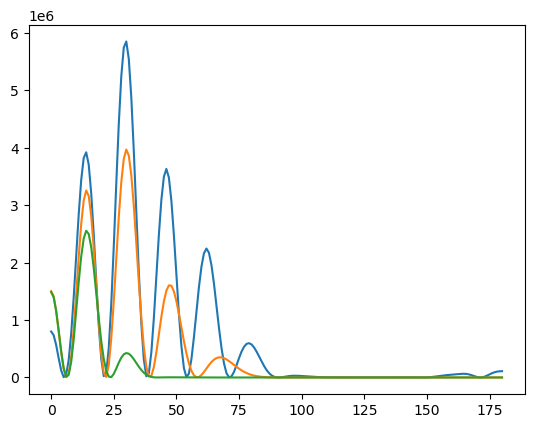

In [19]:
plt.figure()
plt.plot(k_vals, np.abs(se_eq_fft)**2, label='SE')
plt.plot(k_vals, np.abs(fv3_eq_fft)**2, label='FV3')
plt.plot(k_vals, np.abs(mpas_eq_fft)**2, label='MPAS')
plt.show()

In [11]:
# Hmm, fft wasn't great. Let's move to wavelets!
# Try a Gaussian wavelet.